In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load model and test data
model = joblib.load('../models/lgbm_best_model.pkl')

X_test = pd.read_csv('../data/processed/splits/X_test.csv')
y_test = pd.read_csv('../data/processed/splits/y_test.csv').squeeze()

print(f"X_test shape: {X_test.shape}")
print("Model loaded successfully")

X_test shape: (61503, 55)
Model loaded successfully


In [2]:
# Use a sample for speed — 5000 rows is enough for global explanation
X_sample = X_test.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For binary classification LightGBM returns list — take class 1 (default)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values shape: {shap_vals.shape}")
print("SHAP computation complete")

SHAP values shape: (5000, 55)
SHAP computation complete


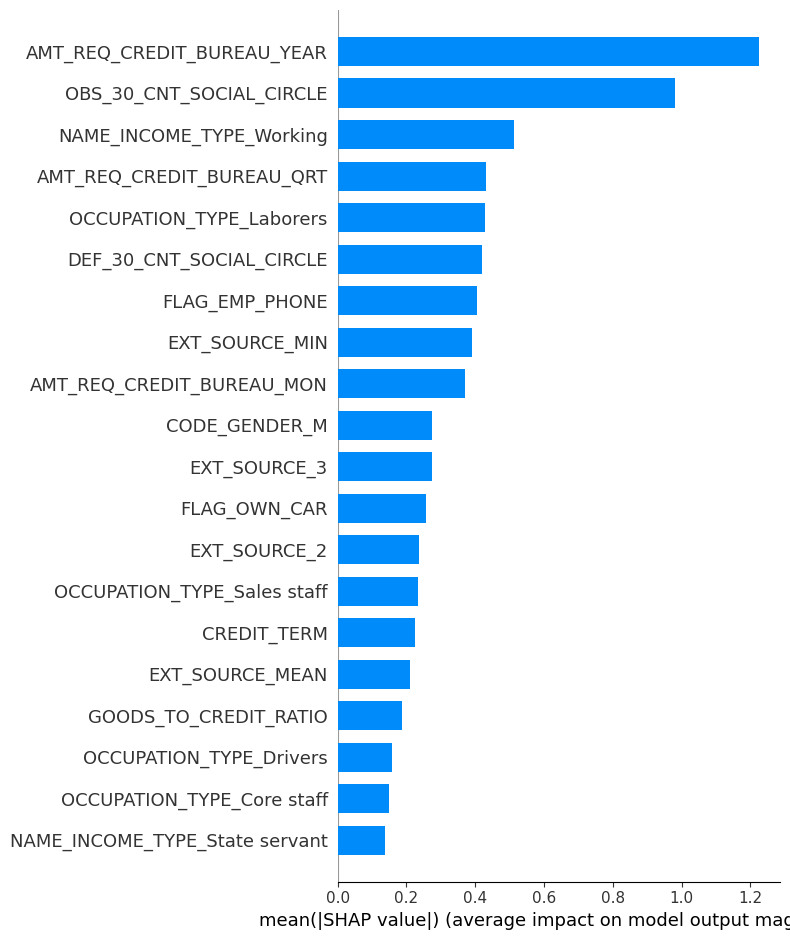

In [3]:
# Summary bar plot — mean absolute SHAP value per feature
shap.summary_plot(
    shap_vals,
    X_sample,
    plot_type='bar',
    max_display=20,
    show=True
)

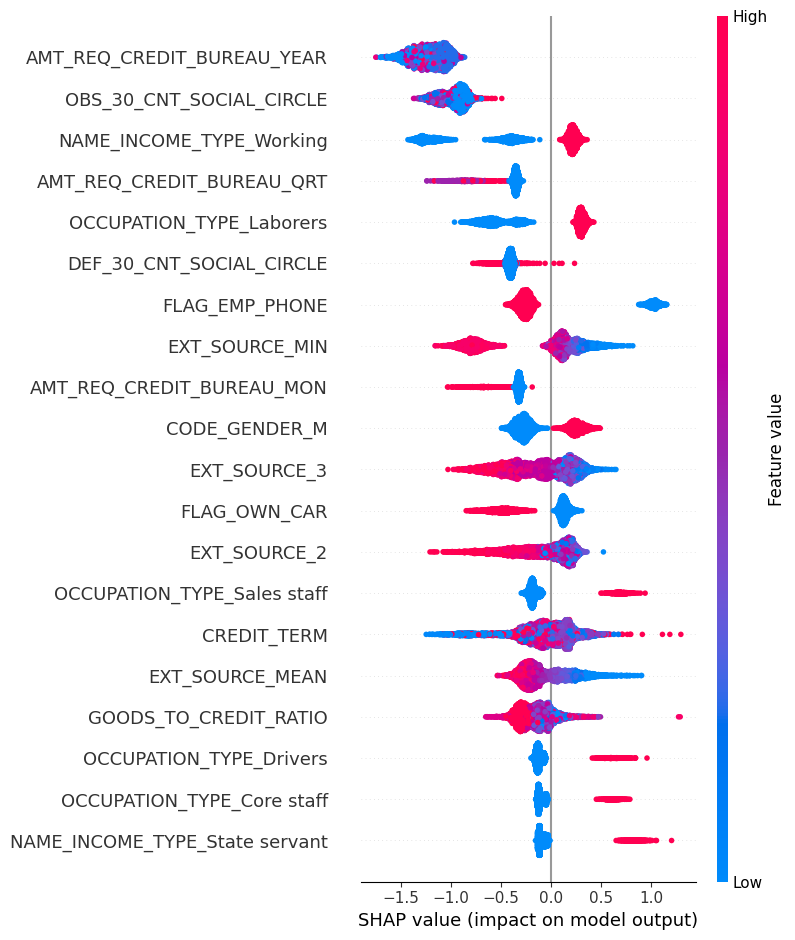

In [4]:
# Summary dot plot — shows direction of impact
shap.summary_plot(
    shap_vals,
    X_sample,
    max_display=20,
    show=True
)

Highest risk customer index: 4738
Predicted default probability: 0.7713


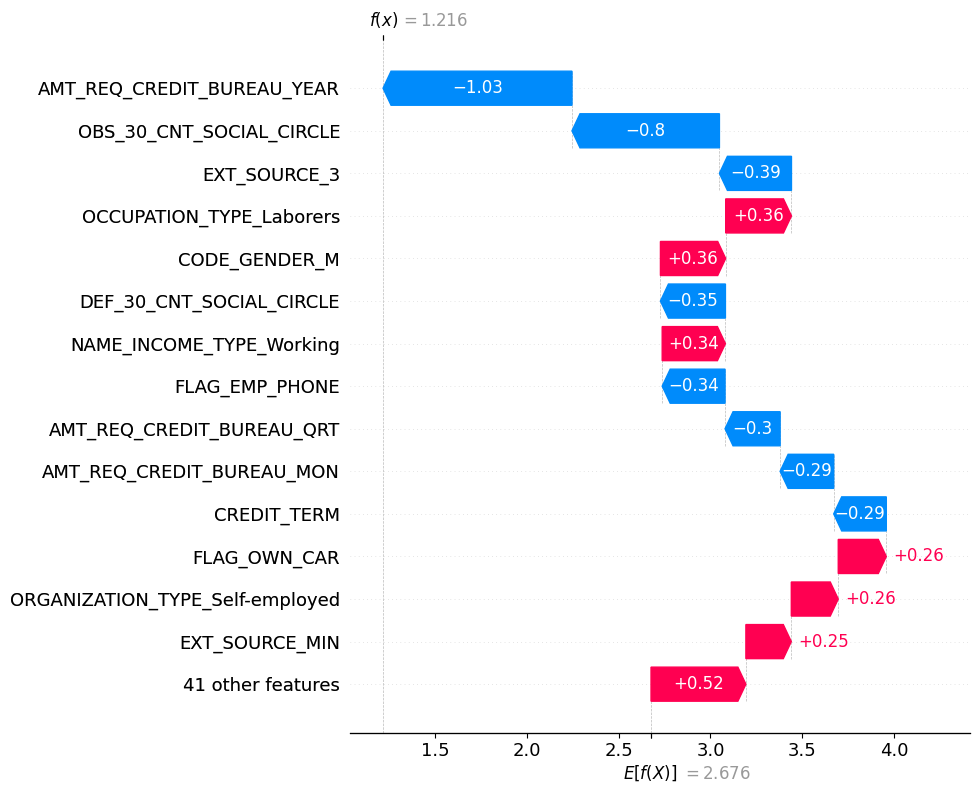

In [5]:
# Explain a single high-risk customer prediction
# Find a customer the model predicted as high default risk
y_prob_sample = model.predict_proba(X_sample)[:, 1]
high_risk_idx = np.argmax(y_prob_sample)

print(f"Highest risk customer index: {high_risk_idx}")
print(f"Predicted default probability: {y_prob_sample[high_risk_idx]:.4f}")

# Waterfall plot for this customer
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) 
    else explainer.expected_value,
    shap_vals[high_risk_idx],
    feature_names=X_sample.columns.tolist(),
    max_display=15,
    show=True
)

Lowest risk customer index: 590
Predicted default probability: 0.0010


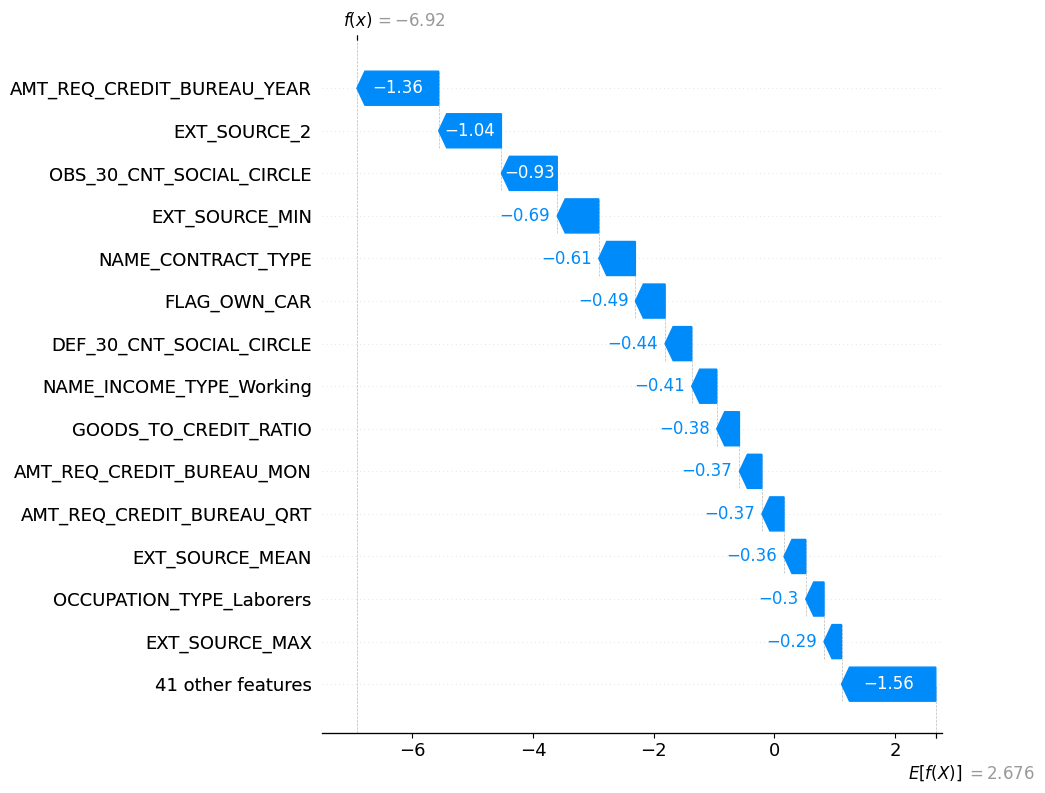

In [6]:
# Find lowest risk customer
low_risk_idx = np.argmin(y_prob_sample)

print(f"Lowest risk customer index: {low_risk_idx}")
print(f"Predicted default probability: {y_prob_sample[low_risk_idx]:.4f}")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    shap_vals[low_risk_idx],
    feature_names=X_sample.columns.tolist(),
    max_display=15,
    show=True
)

In [7]:
shap_df = pd.DataFrame(shap_vals, columns=X_sample.columns)
shap_df.to_csv('../data/processed/shap_values.csv', index=False)
print("SHAP values saved")

SHAP values saved
